# Telco Customer Churn: EDA & Custom Metrics

**Owner:** NMinh (EDA & Metrics) · **Course:** Statistical Learning

This notebook covers NMinh's code tasks.

| Task | Section | Output used by teammates |
|---|---|---|
| 1.10 Centralized Metrics Evaluation | 1, 4 | `src/metrics.py`, `evaluate_model()`, `evaluate_pipeline()` |
| 1.8 Descriptive Statistics & Outliers | 2 | None (Insights for modeling) |
| 1.9 Target Label Distribution | 3 | None (Insights for handling imbalance) |

Run with **Kernel → Restart & Run All**.


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

# Add src to path
project_root = next(
    folder for folder in [Path.cwd(), *Path.cwd().parents]
    if (folder / "src" / "churn_core.py").exists()
)
sys.path.append(str(project_root / "src"))

import churn_core as core
import metrics

# Styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)

# Load data and split
customers_raw = core.load_raw_customers()
customers_clean = core.clean_customers(customers_raw)
X_train, X_test, y_train, y_test = core.split_train_test(customers_clean)

# Merge back for EDA on train set
train_df = X_train.copy()
train_df['Churn'] = y_train


## Task 1.8: Thống kê mô tả và ngoại lai (Tập Train)
Phân tích cho các biến: `tenure`, `MonthlyCharges`, `TotalCharges`.

,Mean,Median,Std,Min,Max,Skewness,Kurtosis,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers Count,Outliers Ratio (%)
Biến,,,,,,,,,,,,,,
tenure,32.4851,29.0000,24.5687,0.0000,72.0000,0.2374,-1.3873,9.0000,55.0000,46.0000,-60.0000,124.0000,0,0.0000
MonthlyCharges,64.9300,70.5000,30.1381,18.4000,118.7500,-0.2244,-1.2604,35.6625,90.0000,54.3375,-45.8437,171.5062,0,0.0000
TotalCharges,2299.3347,1394.9250,2279.2043,0.0000,8684.8000,0.9490,-0.2646,402.9750,3835.8250,3432.8500,-4746.3000,8985.1000,0,0.0000


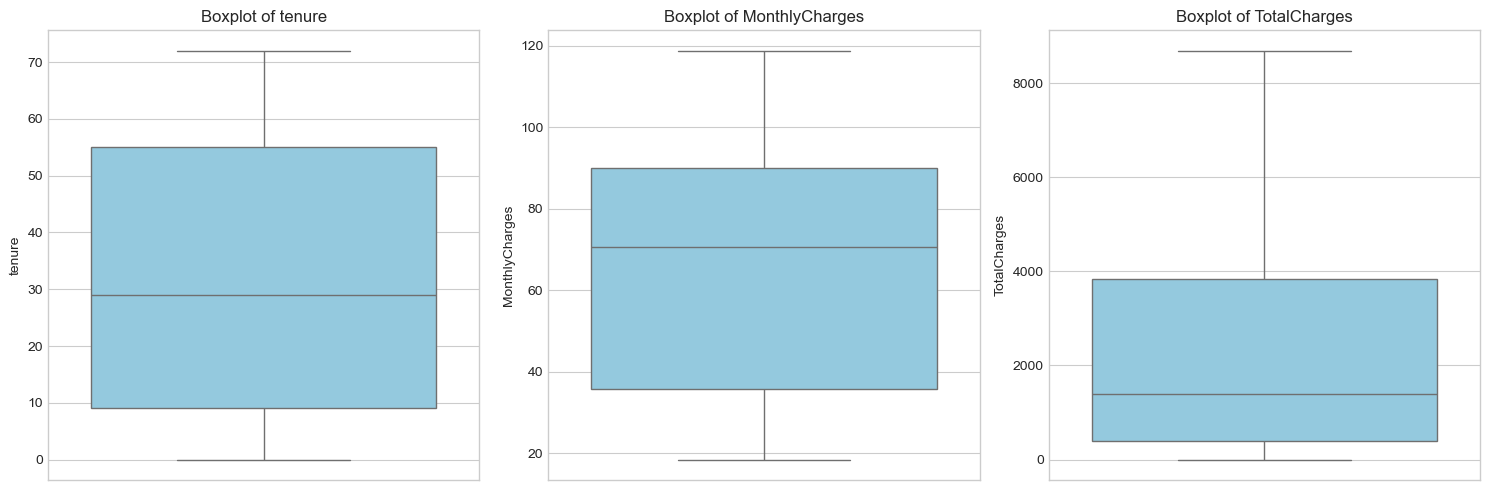

In [2]:
num_vars = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Tính toán các chỉ số
stats_list = []
for col in num_vars:
    s = train_df[col]
    mean = s.mean()
    median = s.median()
    std = s.std()
    vmin, vmax = s.min(), s.max()
    skew = s.skew()
    kurt = s.kurt()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = s[(s < lower) | (s > upper)]
    outlier_count = len(outliers)
    outlier_ratio = outlier_count / len(s) * 100
    
    stats_list.append({
        'Biến': col,
        'Mean': mean, 'Median': median, 'Std': std,
        'Min': vmin, 'Max': vmax,
        'Skewness': skew, 'Kurtosis': kurt,
        'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'Lower Bound': lower, 'Upper Bound': upper,
        'Outliers Count': outlier_count,
        'Outliers Ratio (%)': outlier_ratio
    })

stats_df = pd.DataFrame(stats_list).set_index('Biến')
display(stats_df)

# Boxplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(num_vars):
    sns.boxplot(y=train_df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col}')
plt.tight_layout()

boxplot_path = core.FIGURES_DIR / 'figure_numeric_boxplots.png'
plt.savefig(boxplot_path, dpi=200, bbox_inches='tight')
plt.show()


**Nhận xét (Task 1.8):**
1. Cả 3 biến `tenure`, `MonthlyCharges`, `TotalCharges` đều không có điểm dữ liệu ngoại lai (outliers) nào nằm ngoài khoảng 1.5*IQR, tỷ lệ ngoại lai là 0%.
2. Biến `TotalCharges` có phân phối lệch phải (Skewness > 0), do phần lớn khách hàng mới có tổng cước thấp.
3. Không có ngoại lai bất thường nên các biến này phản ánh đúng thực tế, không bị lỗi thu thập dữ liệu.
4. TotalCharges tương quan thuận rất mạnh (~0.83) với tenure như Tân đã tính, điều này hợp lý vì khách hàng ở lại càng lâu thì tổng cước càng cao.
5. Không bắt buộc phải xử lý log-transform hay loại bỏ ngoại lai trên các biến này do chúng không có ngoại lai cực đoan và scaler chuẩn (StandardScaler) đã được tích hợp trong pipeline.


## Task 1.9: Biểu đồ phân bố nhãn mục tiêu (Tập Train)

C:\Users\DELL\AppData\Local\Temp\ipykernel_4392\1690842114.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=churn_counts.index.map({0: 'No', 1: 'Yes'}), y=churn_counts.values, palette='Set2')


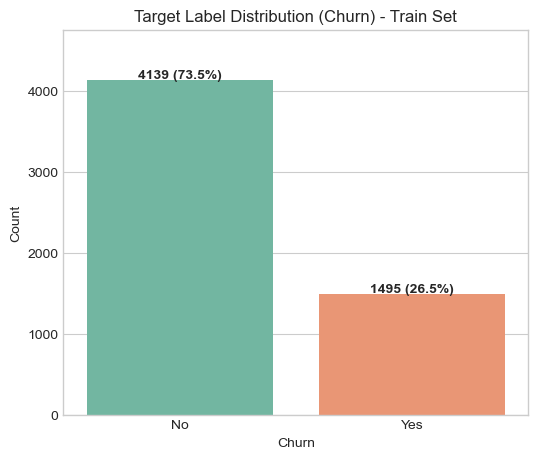

In [3]:
churn_counts = train_df['Churn'].value_counts()
churn_perc = churn_counts / len(train_df) * 100

plt.figure(figsize=(6, 5))
ax = sns.barplot(x=churn_counts.index.map({0: 'No', 1: 'Yes'}), y=churn_counts.values, palette='Set2')
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 20, f'{v} ({churn_perc.iloc[i]:.1f}%)', ha='center', fontweight='bold')

plt.title('Target Label Distribution (Churn) - Train Set')
plt.ylabel('Count')
plt.xlabel('Churn')
plt.ylim(0, max(churn_counts.values) * 1.15)

dist_path = core.FIGURES_DIR / 'figure_churn_distribution.png'
plt.savefig(dist_path, dpi=200, bbox_inches='tight')
plt.show()


**Nhận xét (Task 1.9):**
1. Phân bố nhãn trên tập Train bị lệch (imbalanced) với 73.5% 'No' và 26.5% 'Yes' (đúng với thiết lập stratify ban đầu).
2. Sự mất cân bằng này khiến Accuracy trở thành một metric gây hiểu lầm; ví dụ DummyClassifier đoán toàn 'No' cũng đạt ~73.5% Accuracy dù Recall của lớp Churn bằng 0.
3. Để đánh giá mô hình, ta nên dùng Recall (ưu tiên phát hiện khách hàng rời bỏ) và F1-score (cân bằng giữa Precision và Recall). ROC-AUC cũng rất hữu ích để đo lường khả năng phân tách 2 lớp mà không phụ thuộc vào một ngưỡng cắt (threshold) cố định.
4. Điều này cũng liên hệ trực tiếp tới Task 1.6 của Yến, cần sử dụng các kỹ thuật như SMOTE hoặc tham số `class_weight='balanced'` để giúp mô hình học tốt hơn trên lớp thiểu số (Churn = Yes).


## Task 1.10: Demo Evaluate Pipeline

In [4]:
# Dummy Classifier
dummy_pipe = core.build_model_pipeline(DummyClassifier(strategy='prior', random_state=core.RANDOM_STATE))
dummy_pipe.fit(X_train, y_train)
dummy_res = metrics.evaluate_pipeline(dummy_pipe, X_train, y_train)

# Logistic Regression
logreg_pipe = core.build_model_pipeline(core.make_logistic_regression(penalty='l2'))
logreg_pipe.fit(X_train, y_train)
logreg_res = metrics.evaluate_pipeline(logreg_pipe, X_train, y_train)

# Gom vào bảng metrics
res_table = metrics.metrics_table({
    "Dummy Classifier": dummy_res,
    "Logistic Regression": logreg_res
})
display(res_table)


,accuracy,precision,recall,f1,macro_f1,roc_auc
Dummy Classifier,0.7346,0.0000,0.0000,0.0000,0.4235,0.5000
Logistic Regression,0.8049,0.6584,0.5505,0.5996,0.7353,0.8491
